Install All Required Libraries

Import All the Required Libraries

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load The Dataset


In [44]:
df = pd.read_csv("HousePricePrediction.csv")


In [45]:
type(df)

pandas.core.frame.DataFrame

Statistical Description of Data

In [46]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [47]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [49]:
df.tail()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN


Checking null values

In [50]:
df.isnull()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,False,False,False,False,False,False,False,False,False,False,False,False,True
2915,False,False,False,False,False,False,False,False,False,False,False,False,True
2916,False,False,False,False,False,False,False,False,False,False,False,False,True
2917,False,False,False,False,False,False,False,False,False,False,False,False,True


Preparation Of Data - Exploratory Data Analysis

In [51]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

It calculates how strongly every single numerical feature in your dataset is related to the house's SalePrice, and ranks them from most impactful to least impactful.

In [52]:
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64

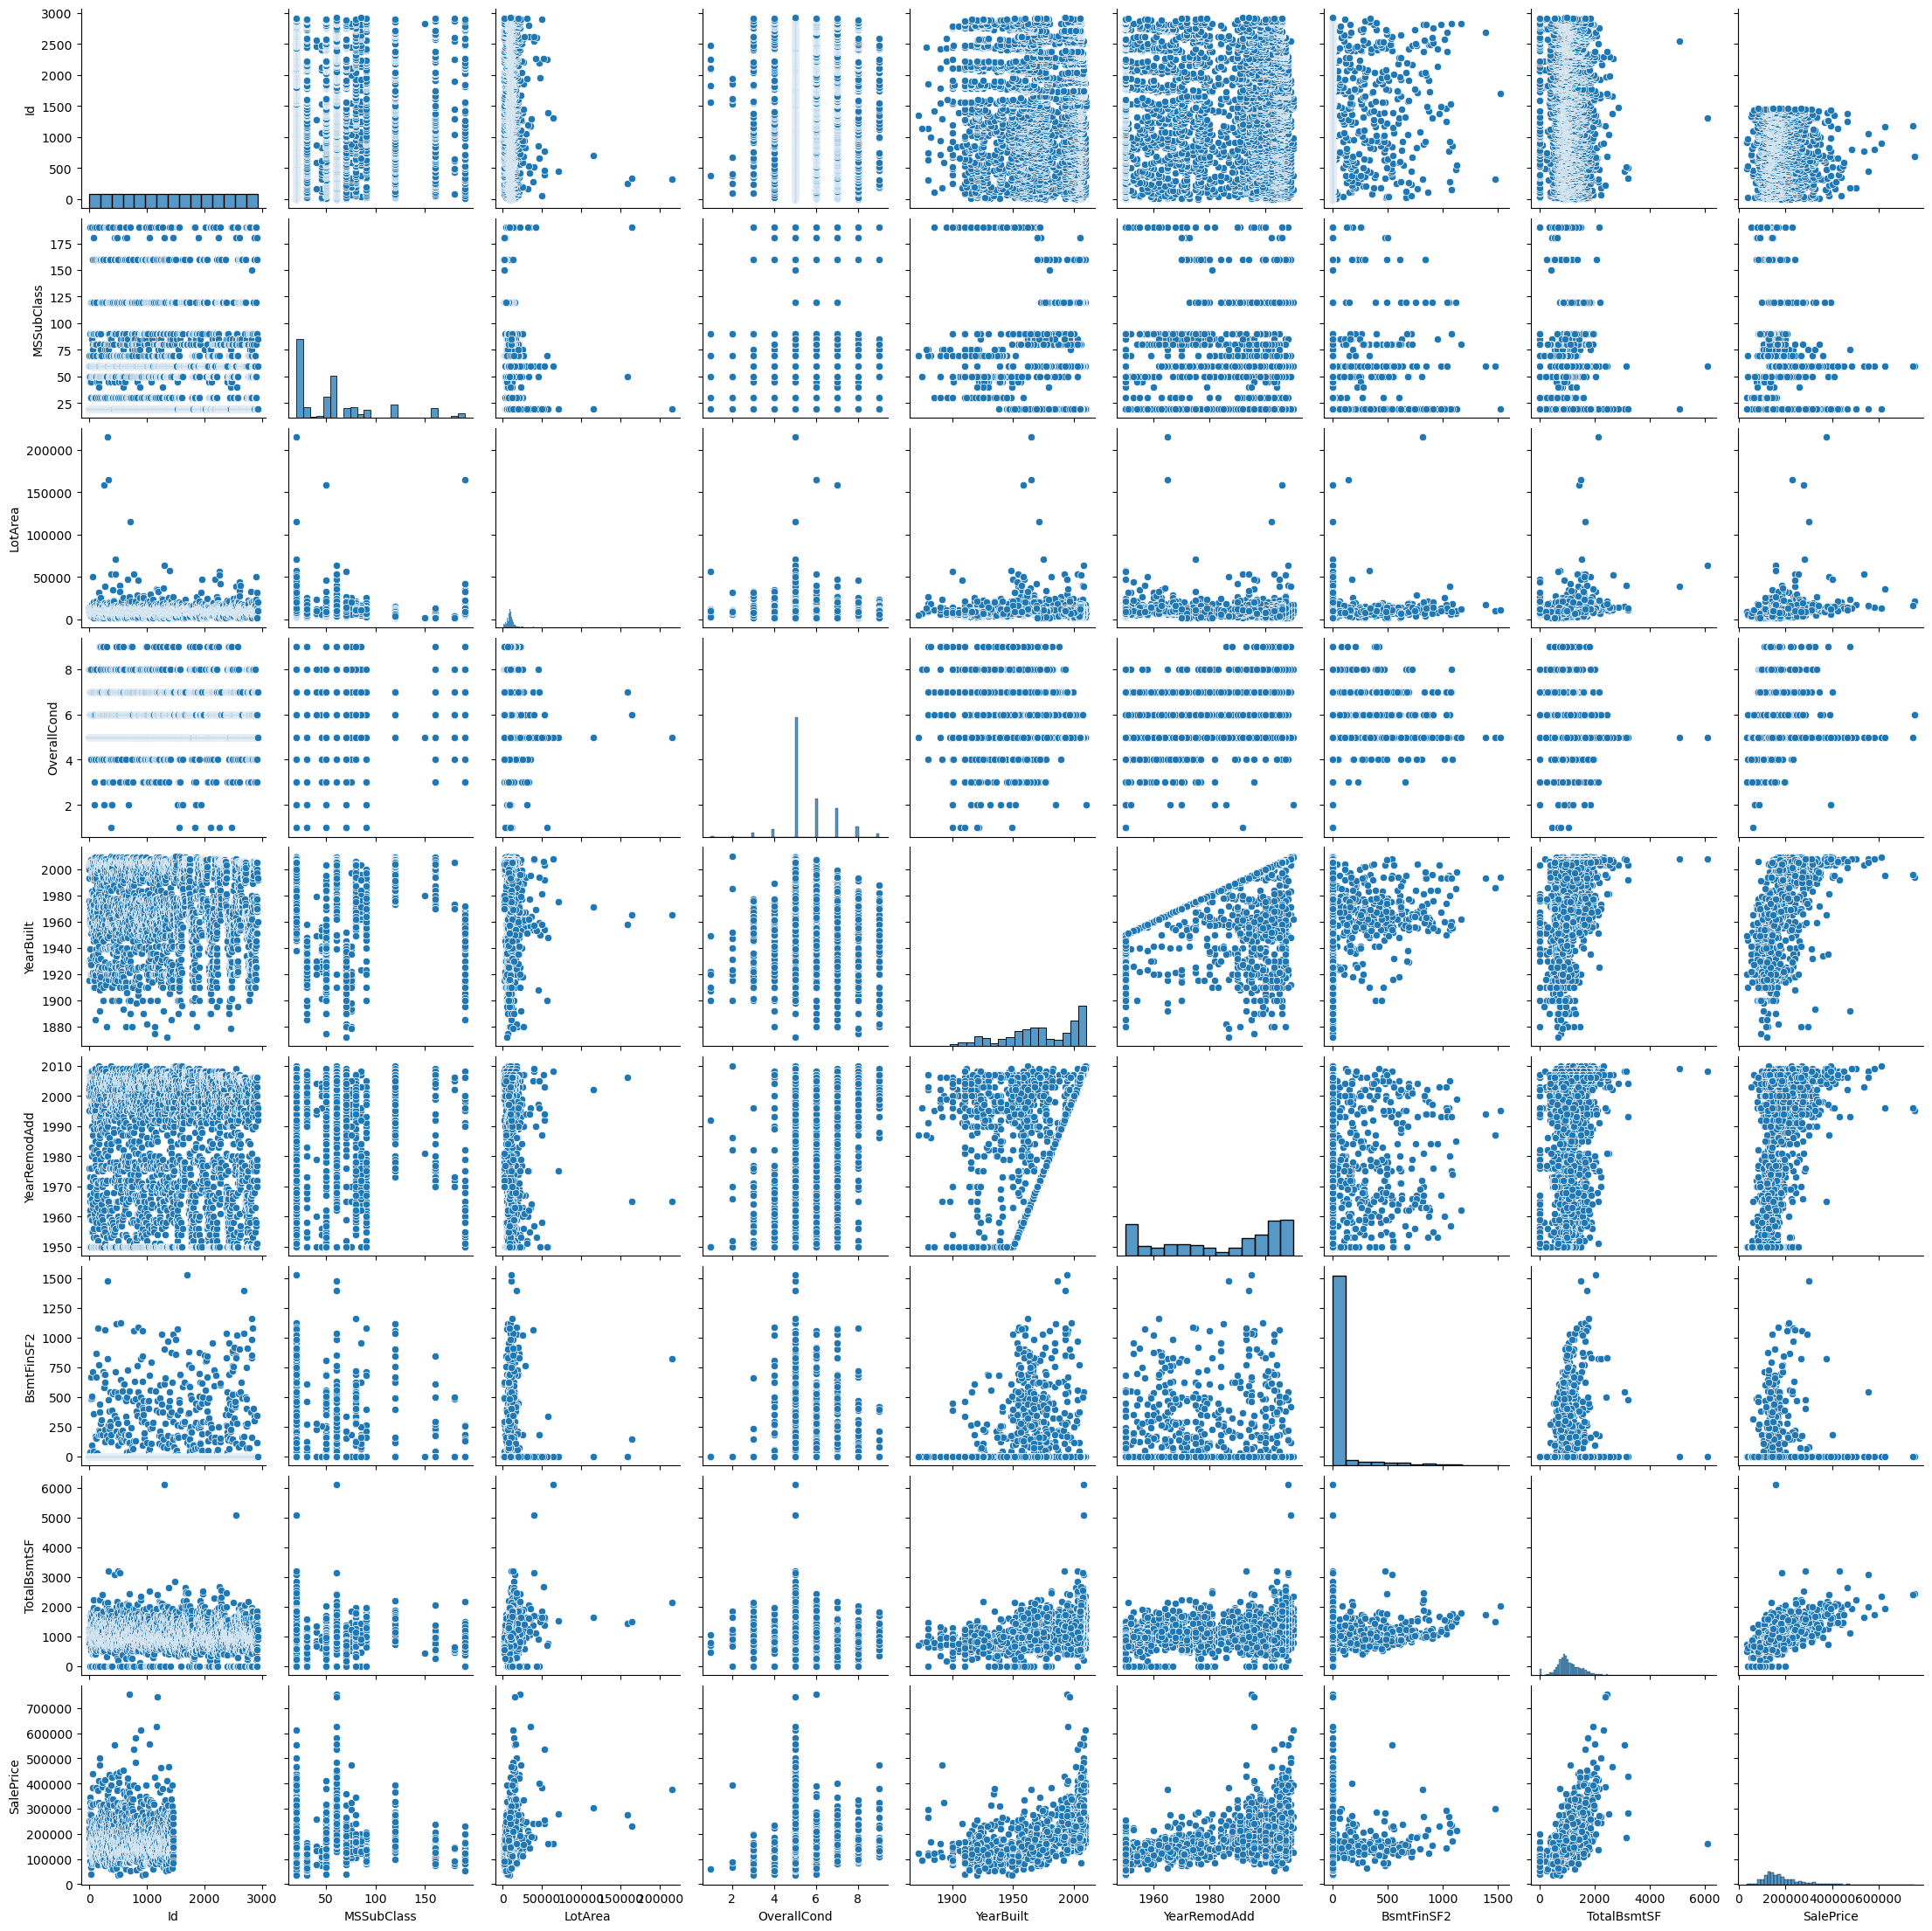

In [53]:
sns.pairplot(df)

Box Plot: It is drawn to detect outliers in a dataset


<Axes: >

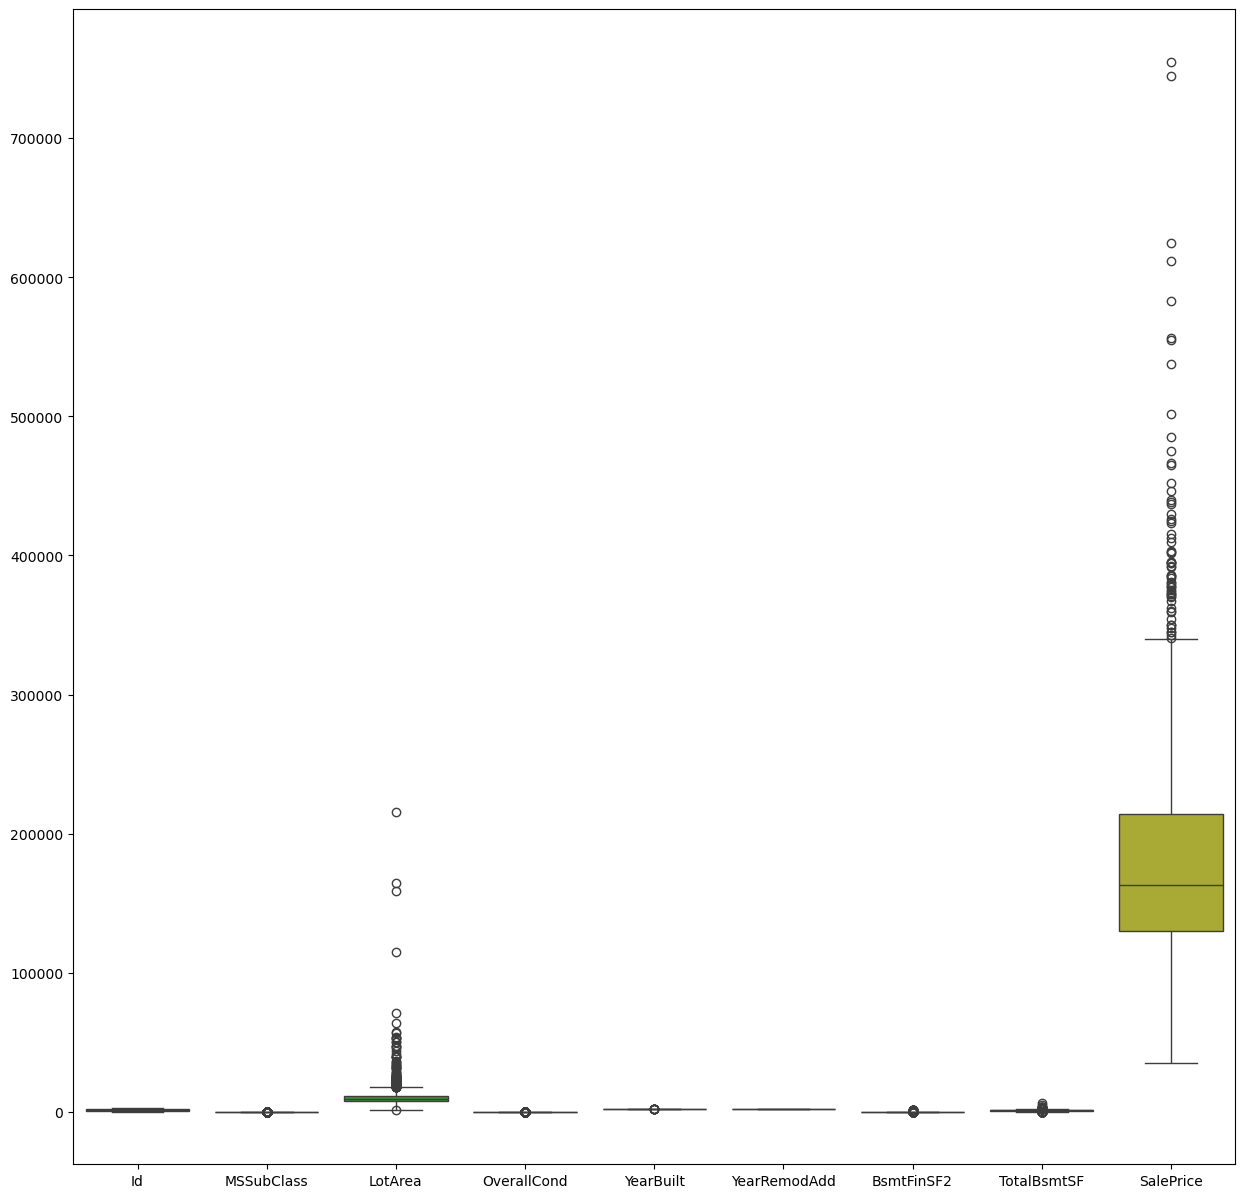

In [54]:
fig, ax = plt.subplots(figsize=(15, 15))
sns.boxplot(data=df, ax=ax)


In [55]:
# Drop rows where target variable (SalePrice) is missing
df.dropna(subset=["SalePrice"], inplace=True)

In [56]:
# IMPROVEMENT 1: Remove Extreme Outliers
# Drop houses with insanely large Lot Areas or Basement Sizes that confuse the model
df = df[df['LotArea'] < 50000]
df = df[df['TotalBsmtSF'] < 3000]

In [57]:
# IMPROVEMENT 2: Feature Engineering
# Create a 'HouseAge' feature, then drop the raw year columns
df['HouseAge'] = df['YearRemodAdd'] - df['YearBuilt']
df.drop(columns=['YearBuilt', 'YearRemodAdd'], inplace=True)

# Separate Features (X) and Target (y)
Where X is the independent Features and Y is the dependent Feature

In [58]:
X = df.drop(columns=["Id", "SalePrice"])
# IMPROVEMENT 3: Log-Transform the Target Variable (SalePrice)
# This makes the heavily skewed house prices look more like a normal bell curve!
Y = df["SalePrice"]

In [59]:
X.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,Exterior1st,BsmtFinSF2,TotalBsmtSF,HouseAge
0,60,RL,8450,Inside,1Fam,5,VinylSd,0.0,856.0,0
1,20,RL,9600,FR2,1Fam,8,MetalSd,0.0,1262.0,0
2,60,RL,11250,Inside,1Fam,5,VinylSd,0.0,920.0,1
3,70,RL,9550,Corner,1Fam,5,Wd Sdng,0.0,756.0,55
4,60,RL,14260,FR2,1Fam,5,VinylSd,0.0,1145.0,0


In [60]:
# Cast MSSubClass to string
X['MSSubClass'] = X['MSSubClass'].astype(str)

In [61]:
Y.head()

0    208500.0
1    181500.0
2    223500.0
3    140000.0
4    250000.0
Name: SalePrice, dtype: float64

Cast MSSubClass to string because it is a categorical feature, not numerical

In [62]:
X["MSSubClass"] = X["MSSubClass"].astype(str)

Identify Numerical and Categorical Columns



In [63]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


Create Preprocessing Pipelines with Imputers (Handles missing values safely!)
For numbers: Fill missing with median -> Scale


In [64]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

For categories: Fill missing with most frequent (mode) -> One-Hot Encode

In [65]:
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

Bundle transformers together

In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_cols),
        ("cat", cat_transformer, categorical_cols)
    ]
)

Build the Final Machine Learning Pipeline

In [67]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

Split the Data into Train and Test

In [68]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [69]:
X_train

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,Exterior1st,BsmtFinSF2,TotalBsmtSF,HouseAge
1445,85,RL,8400,Inside,1Fam,5,VinylSd,627.0,814.0,0
358,80,RL,6930,Inside,1Fam,4,Wd Sdng,294.0,1062.0,0
1102,20,RL,7000,Inside,1Fam,7,Wd Sdng,0.0,1010.0,42
928,20,RL,11838,Inside,1Fam,5,VinylSd,0.0,1753.0,0
693,30,RL,5400,Corner,1Fam,6,MetalSd,0.0,1073.0,47
...,...,...,...,...,...,...,...,...,...,...
1108,60,RL,8063,Inside,1Fam,5,VinylSd,0.0,924.0,0
1143,20,RL,9000,Inside,1Fam,3,Wd Sdng,0.0,1006.0,0
1308,20,RM,12000,Inside,1Fam,7,MetalSd,608.0,924.0,57
873,40,RL,12144,Inside,1Fam,7,HdBoard,0.0,832.0,1


In [70]:
X_test

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,Exterior1st,BsmtFinSF2,TotalBsmtSF,HouseAge
419,20,RL,8450,Inside,1Fam,6,VinylSd,0.0,1056.0,0
319,80,RL,14115,Inside,1Fam,5,Plywood,0.0,1372.0,0
1047,20,RL,9245,Inside,1Fam,5,VinylSd,0.0,990.0,1
66,20,RL,19900,Inside,1Fam,5,Plywood,0.0,1947.0,19
1037,60,RL,9240,Inside,1Fam,5,VinylSd,0.0,1055.0,1
...,...,...,...,...,...,...,...,...,...,...
1120,30,RM,8263,Inside,1Fam,5,BrkFace,0.0,1012.0,30
87,160,FV,3951,Corner,TwnhsE,5,VinylSd,0.0,612.0,0
1386,60,RL,16692,Inside,1Fam,5,Plywood,469.0,1392.0,0
267,75,RL,8400,Inside,1Fam,8,Wd Sdng,0.0,720.0,58


In [71]:
Y_train

1445    129000.0
358     130000.0
1102    135000.0
928     236500.0
693     108480.0
          ...   
1108    181000.0
1143     80000.0
1308    147000.0
873     133000.0
1139    144000.0
Name: SalePrice, Length: 1156, dtype: float64

In [72]:
Y_test

419     142000.0
319     187500.0
1047    145000.0
66      180000.0
1037    287000.0
          ...   
1120    118400.0
87      164500.0
1386    250000.0
267     179500.0
1235    138887.0
Name: SalePrice, Length: 289, dtype: float64

Train the Model (This does imputation, scaling, encoding, and fitting all at once!)

In [73]:
model_pipeline.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotArea', 'OverallCond',
                                                   'BsmtFinSF2', 'TotalBsmtSF',
                                                   'HouseAge']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['MSSubClass', 'MSZoning',
                                                   'LotConfig', 'BldgType',
                                                   'Exterior1st'])])),
                ('model', LinearRegression())])

In [74]:
model_pipeline.named_steps['model'].coef_

array([ 12120.71501243,   5452.3311887 ,  -6304.83051718,  48773.97148102,
          941.14252099,  25985.14591379,  -4261.00290971,  -8668.89929867,
       -23536.49609877, -43827.40696478,    460.22359972, -30044.08734169,
       -13842.20989791,  53469.84080929,  17628.50311703,  18741.72160243,
         9392.20662813, -10555.76656431, -14824.13918508,  57518.00538992,
        41127.18589335,  40230.06868641,  25614.89525793,   6825.58025558,
        -4107.11036176,   6706.60789833,  -1842.11644843, -16920.92405342,
       -14824.13918508, -11491.80727004,   1762.03745092,  74448.74874363,
       -29448.76580818,  13389.01353493, -30486.73247905,  27721.15341745,
       -20497.70011349,  24278.11295128,  -6099.86035882, -17231.24105772,
        63990.22658412,   9097.13500015,   7429.95687551, -11172.96818755,
         3130.46929561])

In [75]:
model_pipeline.named_steps["model"].intercept_

np.float64(145275.5389545784)

Model Prediction

In [76]:
y_pred = model_pipeline.predict(X_test)

In [77]:
y_pred

array([168657.33549526, 225173.75230376, 157865.82919356, 277882.65718946,
       242756.19777178, 169746.83687626, 233652.89935112,  72038.28335393,
       212830.7370073 ,  72038.28335393, 246605.26191997, 145053.5795439 ,
       228327.37054567, 237504.33629219,  88022.19448154, 114573.48477406,
       236762.57746894, 170096.55012977, 168318.27230115, 182205.46347926,
       244457.90368169,  93548.12366828, 245549.21374697, 188923.27966778,
       175302.33809117, 216352.04479141, 113531.96165757, 152469.25755569,
       110841.30503917, 422287.37526361, 230943.06747949, 243759.27206687,
       246105.45001567, 145465.37061487,  93130.20078267, 159178.6538952 ,
       131496.62937945, 220343.87201882, 121065.74209837,  50454.91989076,
       161323.31833844,  68765.7276828 , 137392.94864019, 188183.96093255,
       137385.42961751, 199413.70695717,  74720.06603367, 237904.80961985,
       146581.17156625, 324799.60029254, 144134.92205382, 242281.78359072,
       249201.6283989 , 1

In [78]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(Y_test)

C:\Users\athvi\AppData\Local\Temp\ipykernel_16080\2118591220.py:1: RuntimeWarning: overflow encountered in expm1
  y_pred_actual = np.expm1(y_pred)
c:\Users\athvi\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


Calculate the Error or the Residual

In [79]:
residuals = y_pred - Y_test
residuals

419     26657.335495
319     37673.752304
1047    12865.829194
66      97882.657189
1037   -44243.802228
            ...     
1120    11751.916353
87       4045.260382
1386     9100.324404
267    -16130.482545
1235    23475.018380
Name: SalePrice, Length: 289, dtype: float64

In [80]:
residuals.describe()

count       289.000000
mean       -518.930123
std       45464.891924
min     -332712.624736
25%      -18095.190380
50%        3786.586569
75%       24779.551712
max      105683.960933
Name: SalePrice, dtype: float64

Distribution Plot of the Residuals

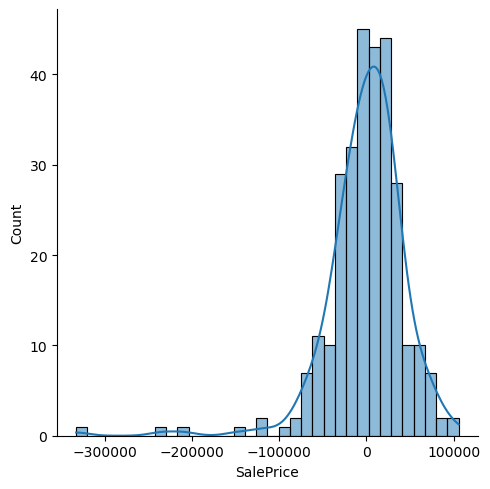

In [81]:
sns.displot(residuals, kde=True)

In [82]:
residuals.mean()

np.float64(-518.9301233244687)

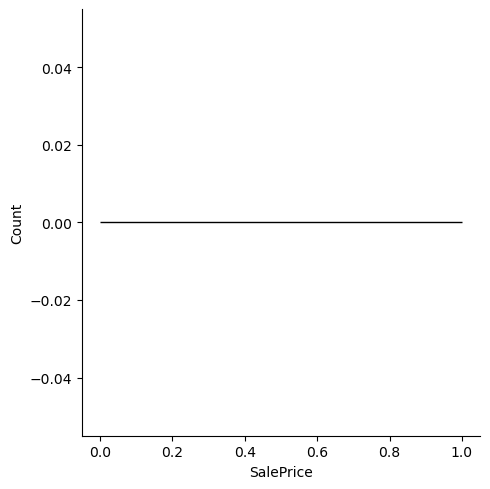

In [83]:
residual2 = y_test_actual - y_pred_actual
sns.displot(residual2, kde=True)

Model Performance

In [84]:
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)

print("--- Linear Regression Model Evaluation ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

--- Linear Regression Model Evaluation ---
R-squared (R2) Score: 0.6673
Mean Absolute Error (MAE): $30,593.16
Root Mean Squared Error (RMSE): $45,389.13


In [86]:
import pickle
pickle.dump(model_pipeline, open("house_price_model.pkl", "wb"))

In [87]:
final_model = pickle.load(open("house_price_model.pkl", "rb"))

final_model.predict(X_test)

array([168657.33549526, 225173.75230376, 157865.82919356, 277882.65718946,
       242756.19777178, 169746.83687626, 233652.89935112,  72038.28335393,
       212830.7370073 ,  72038.28335393, 246605.26191997, 145053.5795439 ,
       228327.37054567, 237504.33629219,  88022.19448154, 114573.48477406,
       236762.57746894, 170096.55012977, 168318.27230115, 182205.46347926,
       244457.90368169,  93548.12366828, 245549.21374697, 188923.27966778,
       175302.33809117, 216352.04479141, 113531.96165757, 152469.25755569,
       110841.30503917, 422287.37526361, 230943.06747949, 243759.27206687,
       246105.45001567, 145465.37061487,  93130.20078267, 159178.6538952 ,
       131496.62937945, 220343.87201882, 121065.74209837,  50454.91989076,
       161323.31833844,  68765.7276828 , 137392.94864019, 188183.96093255,
       137385.42961751, 199413.70695717,  74720.06603367, 237904.80961985,
       146581.17156625, 324799.60029254, 144134.92205382, 242281.78359072,
       249201.6283989 , 1